# Block-Cholesky covariance for the synthetic multilabel dataset

**Purpose**: prototype and inspect a covariance construction where the three blocks
(ρ_cc, ρ_rr, ρ_cr) are controlled **exactly**, with PSD guaranteed **by construction**
— the same `scale_tril` strategy the model uses in `models.py`, applied to data
generation. Candidate replacement / third mode (`cov_structure="block_chol"`) for
`_make_covariance` in `datasets/multilabel_synthetic_dataset.py`.

## Why

The current `"lowrank"` mode scales blocks of Σ directly and then repairs
positive-definiteness by eigenvalue shifting. Two consequences:

- **realized ≠ nominal**: entries are diluted by the rank-L base matrix (~1/√L) and
  the PSD repair cancels ρ_cr beyond ~0.4–0.5 (nominal 0.5 realizes as |ρ| ≈ 0.09).
- **`latent_rank=0` silently disables all ρ's** (returns 1.1·I).

## The construction (conditional-Gaussian / Schur)

You cannot scale blocks of a Cholesky factor L directly — Σ_rr = L_rc L_rcᵀ + L_rr L_rrᵀ
couples the hidden block to the cross block. Instead, pick the **target Σ blocks**
first and *derive* L:

$$\Sigma = \begin{pmatrix} R_{cc} & \rho_{cr} P \\ \rho_{cr} P^\top & R_{rr} \end{pmatrix},
\qquad
L = \begin{pmatrix} L_{cc} & 0 \\ L_{rc} & L_{rr} \end{pmatrix}$$

with $L_{cc} = \mathrm{chol}(R_{cc})$, $L_{rc} = (\rho_{cr} P)^\top L_{cc}^{-\top}$, and
$L_{rr} = \mathrm{chol}(S)$ where $S = R_{rr} - \rho_{cr}^2 P^\top R_{cc}^{-1} P$ is the
Schur complement. Then Σ = LLᵀ reproduces **all three blocks exactly** and sampling is
`η = L z`, `z ~ N(0, I)` — literally the model's `scale_tril` object.

The **single** PD condition is S ≻ 0, checkable in closed form: for paired coupling with
equicorrelated blocks the bound is $\rho_{cr}^2 < (1-\rho_{cc})(1-\rho_{rr})$ (verified
below). Infeasible (ρ_cc, ρ_rr, ρ_cr) combinations **fail loudly with the exact bound**
instead of being silently rescaled.

In [1]:
import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt

# fixed two-hue palette (blue/orange: separates on the CVD-preserved blue-yellow axis)
C_NEW, C_OLD = "#2563EB", "#EA580C"
INK, MUTED = "#1F2937", "#6B7280"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": MUTED, "axes.labelcolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "grid.color": "#E5E7EB", "grid.linewidth": 0.6,
    "figure.dpi": 110,
})
rng = np.random.default_rng(0)
OBS_DIM, HID_DIM = 10, 20  # current default config

## The function

Drop-in candidate for `_make_covariance(..., cov_structure="block_chol")`.

In [2]:
def _within_block_corr(dim, rho, structure, rng, latent_rank=None):
    """Target correlation matrix for one within-channel block.

    structure="equicorr": R = (1-rho) I + rho 11^T. PD iff -1/(dim-1) < rho < 1.
    structure="lowrank":  off-diagonal pattern from a normalized rank-`latent_rank`
        Gram matrix, scaled by rho. PD is checked, not repaired.
    """
    if rho == 0.0 or structure == "identity":
        return np.eye(dim)
    if structure == "equicorr":
        assert -1.0 / (dim - 1) < rho < 1.0, (
            f"equicorr with dim={dim} needs rho in (-{1/(dim-1):.3f}, 1), got {rho}"
        )
        return (1.0 - rho) * np.eye(dim) + rho * np.ones((dim, dim))
    if structure == "lowrank":
        assert latent_rank and latent_rank > 0, "lowrank structure needs latent_rank > 0"
        W = rng.normal(size=(dim, latent_rank))
        base = W @ W.T
        d = np.sqrt(np.diag(base))
        base /= np.outer(d, d)  # correlation-normalized pattern
        np.fill_diagonal(base, 0.0)
        R = np.eye(dim) + rho * base
        min_eig = np.linalg.eigvalsh(R).min()
        assert min_eig > 1e-8, (
            f"lowrank within-block pattern not PD at rho={rho} (min eig {min_eig:.3e}); "
            "lower rho or raise latent_rank -- no silent repair here"
        )
        return R
    raise ValueError(structure)


def max_feasible_rho_cr(R_cc, R_rr, P):
    """Largest |rho_cr| keeping the Schur complement PD, for cross block rho_cr * P.

    S(rho) = R_rr - rho^2 P^T R_cc^{-1} P is PD iff
    rho^2 < 1 / lambda_max(P^T R_cc^{-1} P, R_rr)  (generalized eigenproblem).
    """
    M = P.T @ np.linalg.solve(R_cc, P)
    lam_max = scipy.linalg.eigh(M, R_rr, eigvals_only=True)[-1]
    if lam_max <= 0:
        return np.inf
    return 1.0 / np.sqrt(lam_max)


def make_block_chol_covariance(
    obs_dim,
    hid_dim,
    rho_cc=0.0,
    rho_rr=0.0,
    rho_cr=0.0,
    within="equicorr",
    coupling="paired",
    latent_rank=None,
    rng=None,
    return_factor=False,
):
    """Covariance with exact block control, PSD by construction (no repair).

    Targets are set directly on the covariance blocks:
        Sigma_cc = R_cc            (within-observed correlation, unit diagonal)
        Sigma_rr = R_rr            (within-hidden correlation, unit diagonal)
        Sigma_cr = rho_cr * P      (P = paired-identity coupling pattern)

    and the factor is derived (conditional-Gaussian / Schur construction):
        L_cc = chol(R_cc)
        L_rc = Sigma_cr^T L_cc^{-T}
        L_rr = chol(R_rr - Sigma_cr^T R_cc^{-1} Sigma_cr)

    so Sigma = L L^T reproduces all three blocks exactly. The single PD
    condition is the Schur complement; infeasible (rho_cc, rho_rr, rho_cr)
    combinations fail loudly with the exact feasible bound.
    """
    rng = np.random.default_rng() if rng is None else rng

    R_cc = _within_block_corr(obs_dim, rho_cc, within, rng, latent_rank)
    R_rr = _within_block_corr(hid_dim, rho_rr, within, rng, latent_rank)

    if coupling == "paired":
        P = np.zeros((obs_dim, hid_dim))
        for i in range(min(obs_dim, hid_dim)):
            P[i, i] = 1.0
    else:
        raise ValueError(coupling)
    Sigma_cr = rho_cr * P

    rho_max = max_feasible_rho_cr(R_cc, R_rr, P)
    assert abs(rho_cr) < rho_max, (
        f"rho_cr={rho_cr} infeasible given rho_cc={rho_cc}, rho_rr={rho_rr}: "
        f"need |rho_cr| < {rho_max:.4f}"
    )

    L_cc = np.linalg.cholesky(R_cc)
    L_rc = scipy.linalg.solve_triangular(L_cc, Sigma_cr, lower=True).T
    S = R_rr - Sigma_cr.T @ np.linalg.solve(R_cc, Sigma_cr)
    L_rr = np.linalg.cholesky(S)

    d = obs_dim + hid_dim
    L = np.zeros((d, d))
    L[:obs_dim, :obs_dim] = L_cc
    L[obs_dim:, :obs_dim] = L_rc
    L[obs_dim:, obs_dim:] = L_rr
    Sigma = L @ L.T

    if return_factor:
        return Sigma.astype(np.float32), L.astype(np.float32)
    return Sigma.astype(np.float32)

## Check 1 — exact block recovery, PD without repair

Every (ρ_cc, ρ_rr, ρ_cr) combination should reproduce its target blocks to machine
precision, keep a unit diagonal, and stay PD — with zero repair steps.

In [3]:
def check_exact(cc, rr, cr):
    Sig = make_block_chol_covariance(OBS_DIM, HID_DIM, cc, rr, cr,
                                     rng=np.random.default_rng(0)).astype(np.float64)
    R_cc = (1 - cc) * np.eye(OBS_DIM) + cc * np.ones((OBS_DIM, OBS_DIM))
    R_rr = (1 - rr) * np.eye(HID_DIM) + rr * np.ones((HID_DIM, HID_DIM))
    cross = Sig[:OBS_DIM, OBS_DIM:]
    err_cc = np.abs(Sig[:OBS_DIM, :OBS_DIM] - R_cc).max()
    err_rr = np.abs(Sig[OBS_DIM:, OBS_DIM:] - R_rr).max()
    err_cr = np.abs(np.diag(cross[:, :OBS_DIM]) - cr).max()
    off = cross.copy(); off[range(OBS_DIM), range(OBS_DIM)] = 0.0
    err_zero = np.abs(off).max()
    min_eig = np.linalg.eigvalsh(Sig).min()
    print(f"cc={cc:5.2f} rr={rr:4.2f} cr={cr:4.2f} | block errs: "
          f"{err_cc:.1e} {err_rr:.1e} {err_cr:.1e} | non-paired cross: {err_zero:.1e} "
          f"| min eig {min_eig:6.4f}")
    assert max(err_cc, err_rr, err_cr, err_zero) < 1e-6 and min_eig > 0

for cc, rr, cr in [(0.0, 0.0, 0.5), (0.3, 0.2, 0.5), (0.3, 0.2, 0.0),
                   (0.5, 0.5, 0.4), (-0.05, 0.1, 0.6), (0.0, 0.0, 0.9)]:
    check_exact(cc, rr, cr)
print("\nall exact, all PD, no repair")

cc= 0.00 rr=0.00 cr=0.50 | block errs: 0.0e+00 0.0e+00 0.0e+00 | non-paired cross: 0.0e+00 | min eig 0.5000
cc= 0.30 rr=0.20 cr=0.50 | block errs: 1.2e-08 3.0e-09 0.0e+00 | non-paired cross: 2.8e-17 | min eig 0.2475
cc= 0.30 rr=0.20 cr=0.00 | block errs: 1.2e-08 3.0e-09 0.0e+00 | non-paired cross: 0.0e+00 | min eig 0.7000
cc= 0.50 rr=0.50 cr=0.40 | block errs: 0.0e+00 0.0e+00 6.0e-09 | non-paired cross: 2.8e-17 | min eig 0.1000
cc=-0.05 rr=0.10 cr=0.60 | block errs: 7.5e-10 1.5e-09 2.4e-08 | non-paired cross: 6.9e-18 | min eig 0.2187
cc= 0.00 rr=0.00 cr=0.90 | block errs: 0.0e+00 0.0e+00 2.4e-08 | non-paired cross: 0.0e+00 | min eig 0.1000

all exact, all PD, no repair


## Check 2 — the covariance itself

Signed matrix → diverging colormap centered at 0. You should see: equicorrelated
observed block (ρ_cc), equicorrelated hidden block (ρ_rr), a clean paired diagonal in
the cross block (ρ_cr), zeros elsewhere in the cross block (hidden dims ≥ obs_dim stay
uncorrelated = negative controls, same as the current `"paired"` mode).

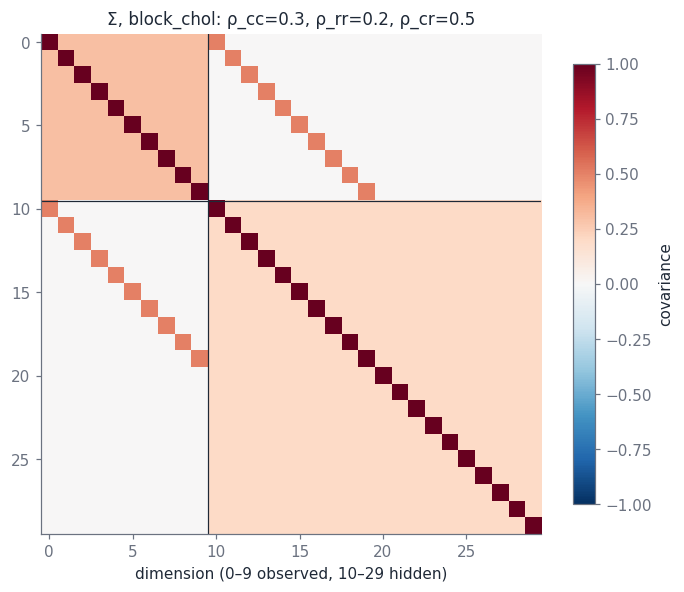

In [4]:
Sig = make_block_chol_covariance(OBS_DIM, HID_DIM, 0.3, 0.2, 0.5,
                                 rng=np.random.default_rng(0))

fig, ax = plt.subplots(figsize=(6.4, 5.6))
im = ax.imshow(Sig, cmap="RdBu_r", vmin=-1, vmax=1)
for b in (OBS_DIM - 0.5,):
    ax.axhline(b, color=INK, lw=0.8)
    ax.axvline(b, color=INK, lw=0.8)
ax.set_title("Σ, block_chol: ρ_cc=0.3, ρ_rr=0.2, ρ_cr=0.5", color=INK, fontsize=11)
ax.set_xlabel("dimension (0–9 observed, 10–29 hidden)")
fig.colorbar(im, ax=ax, shrink=0.8, label="covariance")
plt.tight_layout()
plt.show()

## Check 3 — realized vs nominal ρ_cr: old `"lowrank"` mode vs `block_chol`

The verdict plot. For each nominal ρ_cr, measure the realized mean paired
cross-correlation after the construction (converted to correlation via the realized
diagonal). `block_chol` should sit on the identity line; `lowrank` should show the
dilution + saturation documented in §3 of CLAUDE.md.

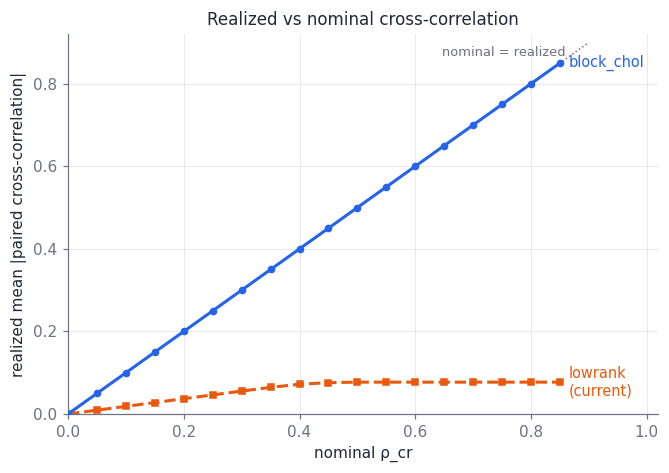

nominal 0.50 -> realized: lowrank 0.077, block_chol 0.500


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
from datasets.multilabel_synthetic_dataset import _make_covariance

nominals = np.linspace(0.0, 0.85, 18)  # step 0.05, includes 0.5 exactly

def realized_paired(Sig):
    Sig = Sig.astype(np.float64)
    d = np.sqrt(np.diag(Sig))
    Corr = Sig / np.outer(d, d)
    return np.mean([abs(Corr[i, OBS_DIM + i]) for i in range(OBS_DIM)])

real_old, real_new = [], []
for cr in nominals:
    # old lowrank mode (latent_rank=10, as in the planned rho_cr sweep)
    vals = [realized_paired(_make_covariance(OBS_DIM, HID_DIM, 10, 0.0, 0.0, cr,
                                             np.random.default_rng(s)))
            for s in range(5)]
    real_old.append(np.mean(vals))
    real_new.append(realized_paired(
        make_block_chol_covariance(OBS_DIM, HID_DIM, 0.0, 0.0, cr,
                                   rng=np.random.default_rng(0))))

fig, ax = plt.subplots(figsize=(6.2, 4.4))
ax.plot([0, 0.9], [0, 0.9], color=MUTED, lw=1, ls=":", zorder=1)
ax.text(0.86, 0.86, "nominal = realized", color=MUTED, fontsize=8.5,
        ha="right", va="bottom")
ax.plot(nominals, real_new, color=C_NEW, lw=2, marker="o", ms=4, zorder=3)
ax.plot(nominals, real_old, color=C_OLD, lw=2, ls="--", marker="s", ms=4, zorder=2)
ax.text(nominals[-1] + 0.015, real_new[-1], "block_chol", color=C_NEW,
        fontsize=9.5, va="center")
ax.text(nominals[-1] + 0.015, real_old[-1], "lowrank\n(current)", color=C_OLD,
        fontsize=9.5, va="center")
ax.set_xlabel("nominal ρ_cr")
ax.set_ylabel("realized mean |paired cross-correlation|")
ax.set_title("Realized vs nominal cross-correlation", color=INK, fontsize=11)
ax.grid(True, axis="both", zorder=0)
ax.set_xlim(0, 1.02); ax.set_ylim(0, 0.92)
plt.tight_layout()
plt.show()

i50 = np.argmin(abs(nominals - 0.5))
print(f"nominal {nominals[i50]:.2f} -> realized: lowrank {real_old[i50]:.3f}, "
      f"block_chol {real_new[i50]:.3f}")

## Check 4 — feasibility frontier is exact and analytic

For paired coupling + equicorrelated blocks, the Schur PD condition should reduce to
ρ_cr² < (1 − ρ_cc)(1 − ρ_rr). Compare the numerical generalized-eigenvalue bound
against that closed form, and confirm the assert triggers just past the bound.

In [6]:
P = np.zeros((OBS_DIM, HID_DIM)); P[range(OBS_DIM), range(OBS_DIM)] = 1.0

print(f"{'rho_cc':>7} {'rho_rr':>7} {'numeric':>9} {'analytic':>9}")
for cc in (0.0, 0.2, 0.3, 0.5, 0.7):
    for rr in (0.0, 0.2, 0.5):
        R_cc = (1 - cc) * np.eye(OBS_DIM) + cc * np.ones((OBS_DIM, OBS_DIM))
        R_rr = (1 - rr) * np.eye(HID_DIM) + rr * np.ones((HID_DIM, HID_DIM))
        num = max_feasible_rho_cr(R_cc, R_rr, P)
        ana = np.sqrt((1 - cc) * (1 - rr))
        print(f"{cc:7.2f} {rr:7.2f} {num:9.4f} {ana:9.4f}")
        assert abs(num - ana) < 1e-8

# the bound is enforced, loudly
rmax = np.sqrt(0.7 * 0.8)
make_block_chol_covariance(OBS_DIM, HID_DIM, 0.3, 0.2, 0.999 * rmax,
                           rng=np.random.default_rng(0))
try:
    make_block_chol_covariance(OBS_DIM, HID_DIM, 0.3, 0.2, 1.001 * rmax,
                               rng=np.random.default_rng(0))
except AssertionError as e:
    print("\njust past the bound ->", e)

 rho_cc  rho_rr   numeric  analytic
   0.00    0.00    1.0000    1.0000
   0.00    0.20    0.8944    0.8944
   0.00    0.50    0.7071    0.7071
   0.20    0.00    0.8944    0.8944
   0.20    0.20    0.8000    0.8000
   0.20    0.50    0.6325    0.6325
   0.30    0.00    0.8367    0.8367
   0.30    0.20    0.7483    0.7483
   0.30    0.50    0.5916    0.5916
   0.50    0.00    0.7071    0.7071
   0.50    0.20    0.6325    0.6325
   0.50    0.50    0.5000    0.5000
   0.70    0.00    0.5477    0.5477
   0.70    0.20    0.4899    0.4899
   0.70    0.50    0.3873    0.3873

just past the bound -> rho_cr=0.749079808832143 infeasible given rho_cc=0.3, rho_rr=0.2: need |rho_cr| < 0.7483


## Check 5 — sampling matches: `η = L z` end to end

Draw samples the way the dataset generator would (`eta = z @ L.T`) and confirm the
empirical correlation matches nominal — including binary-concept phi correlation after
thresholding at 0, which is what the SCBM actually sees.

In [7]:
Sig, L = make_block_chol_covariance(OBS_DIM, HID_DIM, 0.3, 0.2, 0.5,
                                    rng=np.random.default_rng(0), return_factor=True)
z = np.random.default_rng(42).standard_normal((200_000, OBS_DIM + HID_DIM))
eta = z @ L.T.astype(np.float64)

emp = np.corrcoef(eta.T)
paired = np.array([emp[i, OBS_DIM + i] for i in range(OBS_DIM)])
print(f"latent paired cross-corr:  mean {paired.mean():.4f}  (nominal 0.5), "
      f"max |dev| {np.abs(paired - 0.5).max():.4f}")

conc = (eta > 0).astype(float)  # binary concepts, threshold at 0
phi = np.corrcoef(conc.T)
phi_paired = np.array([phi[i, OBS_DIM + i] for i in range(OBS_DIM)])
# for bivariate normal with corr rho, phi of the 0-thresholded binaries = 2/pi * arcsin(rho)
expected_phi = 2 / np.pi * np.arcsin(0.5)
print(f"binary paired phi-corr:    mean {phi_paired.mean():.4f}  "
      f"(theory 2/π·arcsin(0.5) = {expected_phi:.4f})")

latent paired cross-corr:  mean 0.4990  (nominal 0.5), max |dev| 0.0029
binary paired phi-corr:    mean 0.3336  (theory 2/π·arcsin(0.5) = 0.3333)


## Verdict checklist

- [ ] **Check 1**: all block errors at machine precision, min eig > 0, no repair path.
- [ ] **Check 2**: heatmap shows exactly the three intended blocks; non-paired cross
  entries are exactly 0 (negative controls preserved).
- [ ] **Check 3**: block_chol on the identity line; lowrank diluted/saturated
  (nominal 0.5 → realized ≈ 0.09).
- [ ] **Check 4**: feasibility bound = √((1−ρ_cc)(1−ρ_rr)) exactly; infeasible combos
  raise with the bound in the message.
- [ ] **Check 5**: sampled latent corr ≈ nominal; thresholded-binary phi matches the
  2/π·arcsin(ρ) theory value.

If all boxes tick, integration is a third `cov_structure="block_chol"` branch in
`_make_covariance` (the existing `"paired"` mode is the special case
ρ_cc = ρ_rr = 0, so it could be subsumed), plus a realized-vs-nominal line in
`info.txt`. `latent_rank` then only matters if `within="lowrank"` is chosen — it no
longer silently gates whether the ρ's do anything.